# Imports

In [1]:
import os, gc, time, json, warnings
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Configuration¶

In [2]:
import random  # Add this line
import numpy as np
import torch
from pathlib import Path

def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input/datasets/rayaanraza1/ninapro-db7')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    # Corrected the fallback path to match your specific dataset location if needed
    return r if r else Path('/kaggle/input/datasets/rayaanraza1/ninapro-db7')

class Config:
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_MKA'      
    DATA_CACHE_DIR = KAGGLE_WORKING / 'cache_exB'      
    PLOT_DIR       = KAGGLE_WORKING / 'plots_MKA'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_MKA'

    SUBJECTS       = list(range(1, 23))
    EMG_FS         = 2000          
    ACC_FS         = 148           
    TARGET_FS      = 2000          

    EMG_KEY        = 'emg'
    ACC_KEY        = 'acc'
    LBL_KEY        = 'restimulus'
    GESTURE_MIN    = 13            
    GESTURE_MAX    = 29

    WIN_MS         = 200           
    STEP_MS        = 100           
    WIN_SAMPLES    = int(WIN_MS  * TARGET_FS / 1000)
    STEP_SAMPLES   = int(STEP_MS * TARGET_FS / 1000)

    SPLIT_RATIOS = [
          (0.90, 0.10)
    ]
    VAL_FRAC_OF_TRAIN = 0.10

    MIN_EPOCHS     = 100
    MAX_EPOCHS     = 150
    PATIENCE       = 20            
    BATCH_SIZE     = 256
    LR             = 1e-3
    WEIGHT_DECAY   = 1e-4
    NUM_WORKERS    = 2
    SEED           = 42
    DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Seed setting for reproducibility
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

# Directory setup
for d in [Config.CKPT_DIR, Config.DATA_CACHE_DIR,
          Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device  : {Config.DEVICE}")
print(f"Gestures: {Config.GESTURE_MIN}–{Config.GESTURE_MAX} (17 classes)")
print(f"Splits  : {Config.SPLIT_RATIOS}")

Device  : cuda
Gestures: 13–29 (17 classes)
Splits  : [(0.9, 0.1)]


In [3]:
import random

random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)

if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for d in [Config.CKPT_DIR, Config.DATA_CACHE_DIR,
          Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device  : {Config.DEVICE}")
print(f"Win     : {Config.WIN_SAMPLES} samples ({Config.WIN_MS} ms)")
print(f"Step    : {Config.STEP_SAMPLES} samples ({Config.STEP_MS} ms)")
print(f"Gestures: {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.GESTURE_MAX - Config.GESTURE_MIN + 1} classes)")

Device  : cuda
Win     : 400 samples (200 ms)
Step    : 200 samples (100 ms)
Gestures: 13–29 (17 classes)


# DATA LOADING (EMG + ACC + labels)

In [4]:
class EMGAccPreprocessor:
    def _find_key(self, data, candidates):
        for c in candidates:
            for k in data:
                if k.lower() == c.lower():
                    return k
        return None

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY, 'glove'])
        lbl_key = self._find_key(data, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])

        if emg_key is None:
            raise KeyError(f"No EMG key in {mat_path.name}")
        if lbl_key is None:
            raise KeyError(f"No label key in {mat_path.name}")
            
        emg = data[emg_key].astype(np.float32)
        labels = data[lbl_key].flatten().astype(np.int32)

        if acc_key is not None:
            acc = data[acc_key].astype(np.float32)
            if len(acc) != len(emg):
                factor = len(emg) / len(acc)
                up = round(factor * Config.ACC_FS)
                down = Config.ACC_FS
                g = gcd(up, down)
                acc = resample_poly(acc, up // g, down // g, axis=0).astype(np.float32)
            if len(acc) > len(emg):
                acc = acc[:len(emg)]
            elif len(acc) < len(emg):
                pad = np.zeros((len(emg) - len(acc), acc.shape[1]), dtype=np.float32)
                acc = np.vstack([acc, pad])
        else:
            acc = np.zeros((len(emg), 0), dtype=np.float32)

        n = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]

        mask = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        emg = emg[mask]
        acc = acc[mask]
        labels = labels[mask]

        return emg, acc, labels

# Subject Loader

In [5]:
class SubjectLoader:
    def __init__(self):
        self.preprocessor = EMGAccPreprocessor()
        self.cache_dir = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid: int) -> Path:
        return self.cache_dir / f'subj_{sid:02d}_exB.npz'

    def _find_subject_dir(self, sid: int) -> Path:
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for p in candidates:
            if p.is_dir():
                return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(f"Cannot locate folder for subject {sid}")

    def _load_subject(self, sid: int):
        subj_dir = self._find_subject_dir(sid)
        mat_files = sorted(subj_dir.glob('*.mat'))
        if not mat_files:
            mat_files = sorted(subj_dir.rglob('*.mat'))

        emg_parts, acc_parts, lbl_parts = [], [], []
        for mat_file in mat_files:
            try:
                emg, acc, lbl = self.preprocessor.apply(mat_file)
                if len(emg) > 0:
                    emg_parts.append(emg)
                    acc_parts.append(acc)
                    lbl_parts.append(lbl)
            except Exception as e:
                print(f"    Skip {mat_file.name}: {e}")

        if not emg_parts:
            raise RuntimeError(f"No valid data for subject {sid}")

        emg_all = np.vstack(emg_parts)
        acc_all = np.vstack(acc_parts) if all(a.shape[1] > 0 for a in acc_parts) else np.zeros((sum(len(e) for e in emg_parts), 0), dtype=np.float32)
        lbl_all = np.concatenate(lbl_parts)
        return emg_all, acc_all, lbl_all

    def process_all(self, subjects=None):
        subjects = subjects or Config.SUBJECTS
        available = []
        n_acc_ch = None

        for sid in tqdm(subjects, desc='Loading subjects'):
            ckpt = self._ckpt_path(sid)
            if ckpt.exists():
                data = np.load(ckpt, allow_pickle=True)
                n_acc_ch = int(data['n_acc_ch'])
                available.append(sid)
                print(f"  Subject {sid:02d}: checkpoint found ({data['n_rows']} rows)")
                continue
            try:
                emg, acc, lbl = self._load_subject(sid)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(
                    ckpt,
                    emg=emg, acc=acc, labels=lbl,
                    n_acc_ch=np.array(n_acc_ch),
                    n_rows=np.array(len(emg)),
                )
                available.append(sid)
                print(f"  Subject {sid:02d}: saved {len(emg):,} rows")
                del emg, acc, lbl
                gc.collect()
            except Exception as exc:
                print(f"  Subject {sid:02d}: FAILED — {exc}")

        return available, (n_acc_ch or 0)

    def build_windows(self, subjects, n_acc_ch):
        W = Config.WIN_SAMPLES
        S = Config.STEP_SAMPLES
        X_list, y_list = [], []

        for sid in tqdm(subjects, desc='Windowing'):
            ckpt = self._ckpt_path(sid)
            if not ckpt.exists():
                continue
            d = np.load(ckpt)
            emg = d['emg'].astype(np.float32)
            acc = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)

            sig = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            n_ch = sig.shape[1]
            T = len(sig)

            for start in range(0, T - W + 1, S):
                end = start + W
                seg = sig[start:end]
                lbls = labels[start:end]
                lbl = int(np.bincount(lbls - Config.GESTURE_MIN, minlength=Config.GESTURE_MAX - Config.GESTURE_MIN + 1).argmax())
                X_list.append(seg.T)
                y_list.append(lbl)

            del emg, acc, labels, sig, d
            gc.collect()

        X = np.stack(X_list, axis=0).astype(np.float32)
        y = np.array(y_list, dtype=np.int64)
        return X, y, n_ch

# Normalization

In [6]:
class ChannelNormalizer:
    def __init__(self):
        self.mean = None
        self.std  = None

    def fit(self, X: np.ndarray):
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std  = X.std(axis=(0, 2), keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean) / self.std

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

# Torch Dataset

In [7]:
class EMGWindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Multi-Kernel Attention 1D CNN Model

In [8]:
class _ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool1d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [9]:
class AttentionBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(in_ch, in_ch // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(in_ch // 4, in_ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attention(x)

class MultiKernelAttention1DCNN(nn.Module):
    def __init__(self, n_channels: int, n_classes: int, dropout: float = 0.3):
        super().__init__()
        self.n_channels = n_channels
        
        self.features = nn.Sequential(
            _ConvBlock(n_channels, 64, kernel=7, pool=True),
            AttentionBlock(64),
            _ConvBlock(64, 128, kernel=5, pool=True),
            AttentionBlock(128),
            _ConvBlock(128, 256, kernel=3, pool=False),
        )
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Compute GFLOPs


In [10]:
def compute_gflops(model, n_channels, win_samples=Config.WIN_SAMPLES):
    if HAS_THOP:
        dummy = torch.zeros(1, n_channels, win_samples)
        macs, _ = thop_profile(deepcopy(model).cpu(), inputs=(dummy,), verbose=False)
        return macs * 2 / 1e9
    else:
        return -1.0

# Trainer

In [11]:
class Trainer:
    def __init__(self, model, save_path: Path, n_classes: int):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.n_classes = n_classes
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, y in loader:
                X, y = X.to(Config.DEVICE), y.to(Config.DEVICE)
                logits = self.model(X)
                loss = criterion(logits, y)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * len(y)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        return total_loss / total, correct / total

    def fit(self, train_loader, val_loader):
        optimizer = Adam(self.model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.MAX_EPOCHS)

        best_val_loss = float('inf')
        patience_cnt = 0
        start_wall = time.perf_counter()
        
        for epoch in range(1, Config.MAX_EPOCHS + 1):
            tr_loss, tr_acc = self._run_epoch(train_loader, optimizer, criterion)
            vl_loss, vl_acc = self._run_epoch(val_loader, criterion=criterion)
            scheduler.step()

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            if vl_loss < best_val_loss:
                best_val_loss = vl_loss
                patience_cnt = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"  Epoch {epoch:3d}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}")

            if epoch >= Config.MIN_EPOCHS and patience_cnt >= Config.PATIENCE:
                print(f"  Early stop at epoch {epoch} (patience={Config.PATIENCE})")
                break

        self.train_wall = time.perf_counter() - start_wall
        print(f"  Training wall-clock: {self.train_wall:.1f} s | Best val_loss: {best_val_loss:.4f}")
        return self

# Evaluator

In [12]:
class Evaluator:
    def __init__(self, model_cls, model_kwargs, save_path: Path, n_classes: int, class_names: list):
        self.model_cls = model_cls
        self.model_kwargs = model_kwargs
        self.save_path = save_path
        self.n_classes = n_classes
        self.class_names = class_names

    def _load_model(self):
        model = self.model_cls(**self.model_kwargs)
        model.load_state_dict(torch.load(self.save_path, map_location=Config.DEVICE))
        model.to(Config.DEVICE).eval()
        return model

    def evaluate(self, test_loader, split_tag: str) -> dict:
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(Config.DEVICE)
                logits = model(X)
                proba = torch.softmax(logits, dim=1).cpu().numpy()
                preds = logits.argmax(1).cpu().numpy()
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall
        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)
        n_test = len(all_true)

        acc_overall = accuracy_score(all_true, all_preds)
        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(accuracy_score(all_true[mask], all_preds[mask]))

        precision = precision_score(all_true, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_true, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)
        
        try:
            roc_auc = roc_auc_score(all_true, all_proba, multi_class='ovr', average='weighted', labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        gflops = compute_gflops(model, model.n_channels)

        metrics = {
            'split': split_tag,
            'accuracy': acc_overall,
            'precision_w': precision,
            'recall_w': recall,
            'f1_w': f1,
            'roc_auc_w': roc_auc,
            'per_class_acc': per_class_acc,
            'test_wall_s': test_wall,
            'test_samples': n_test,
            'gflops_per_window': gflops,
            'input_size': f"(1, {model.n_channels}, {Config.WIN_SAMPLES})",
        }

        tag = split_tag.replace(':', '_')
        self._plot_confusion(all_true, all_preds, split_tag, tag)
        self._plot_roc(all_true, all_proba, split_tag, tag)

        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm = confusion_matrix(y_true, y_pred, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, label in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names, annot=(self.n_classes <= 17), fmt='.2f' if label == 'Normalised' else 'd', linewidths=0.3)
            ax.set_title(f"Confusion Matrix ({label}) — {title}", fontsize=11)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0, labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2, label=f"{self.class_names[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {title}", fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

# LEARNING-CURVE PLOTTER

In [13]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss')
    axes[0].plot(epochs, history['val_loss'], label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'Learning Curve (Loss) — {split_tag}')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc')
    axes[1].plot(epochs, history['val_acc'], label='Val acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Learning Curve (Accuracy) — {split_tag}')
    axes[1].legend()

    plt.tight_layout()
    tag = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show() 
    plt.close('all')
    print(f"    Curves saved → {path.name}")

# EXPERIMENT RUNNER (one split ratio)

In [14]:
class SplitExperiment:
    def __init__(self, X: np.ndarray, y: np.ndarray, n_channels: int, n_classes: int, class_names: list):
        self.X = X
        self.y = y
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.class_names = class_names

    def run(self, train_frac: float, test_frac: float) -> dict:
        tag = f"{int(train_frac*100)}:{int(test_frac*100)}"
        print(f"\n{'='*70}")
        print(f"  Split  {tag}  |  train={train_frac:.0%}  test={test_frac:.0%}")
        print(f"{'='*70}")

        X_trainval, X_test, y_trainval, y_test = train_test_split(
            self.X, self.y,
            test_size=test_frac,
            random_state=Config.SEED,
            stratify=self.y,
        )

        if len(np.unique(y_trainval)) < self.n_classes:
            stratify_tv = None
        else:
            stratify_tv = y_trainval

        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval,
            test_size=Config.VAL_FRAC_OF_TRAIN,
            random_state=Config.SEED,
            stratify=stratify_tv,
        )

        print(f"  Sizes  train={len(y_train):,}  val={len(y_val):,}  test={len(y_test):,}")

        normalizer = ChannelNormalizer()
        X_train = normalizer.fit_transform(X_train)
        X_val = normalizer.transform(X_val)
        X_test = normalizer.transform(X_test)

        tr_loader = DataLoader(EMGWindowDataset(X_train, y_train), batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
        val_loader = DataLoader(EMGWindowDataset(X_val, y_val), batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
        tst_loader = DataLoader(EMGWindowDataset(X_test, y_test), batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

        model_kwargs = dict(n_channels=self.n_channels, n_classes=self.n_classes)
        model = MultiKernelAttention1DCNN(**model_kwargs)
        save_path = Config.CKPT_DIR / f'mka_1d_cnn_{tag.replace(":", "_")}.pt'
        gflops = compute_gflops(model, self.n_channels)
        
        print(f"  Multi-Kernel Attention 1D CNN params : {model.count_params():,}")
        print(f"  GFLOPs/window  : {gflops:.4f}  (input {model_kwargs['n_channels']}×{Config.WIN_SAMPLES})")
        
        trainer = Trainer(model, save_path, self.n_classes)
        trainer.fit(tr_loader, val_loader)
        plot_learning_curves(trainer.history, tag)

        evaluator = Evaluator(MultiKernelAttention1DCNN, model_kwargs, save_path, self.n_classes, self.class_names)
        metrics, y_true, y_proba = evaluator.evaluate(tst_loader, tag)

        metrics['train_wall_s'] = trainer.train_wall
        metrics['gflops_per_window'] = gflops
        metrics['n_params'] = model.count_params()
        metrics['epochs_trained'] = len(trainer.history['train_loss'])
        metrics['train_size'] = int(len(y_train))
        metrics['val_size'] = int(len(y_val))
        metrics['test_size'] = int(len(y_test))

        print(f"\n  Results  {tag}")
        print(f"    Accuracy      : {metrics['accuracy']:.4f}")
        print(f"    Precision (W) : {metrics['precision_w']:.4f}")
        print(f"    Recall (W)    : {metrics['recall_w']:.4f}")
        print(f"    F1 (W)        : {metrics['f1_w']:.4f}")
        print(f"    ROC-AUC (W)   : {metrics['roc_auc_w']:.4f}")
        print(f"    Train wall    : {metrics['train_wall_s']:.1f} s")
        print(f"    Test wall     : {metrics['test_wall_s']:.2f} s")
        print(f"    GFLOPs/win    : {gflops:.4f}")
        print(f"    Model saved → {save_path.name}")

        return metrics, y_true, y_proba

# Failure Mode Ananlysis

In [15]:
def analyse_failure_modes(all_metrics: list, class_names: list):
    print(f"\n{'='*70}")
    print("  FAILURE MODE ANALYSIS (Multi-Kernel Attention 1D CNN)")
    print(f"{'='*70}")

    class_accs = {c: [] for c in class_names}
    for m in all_metrics:
        for c, acc in m.get('per_class_acc', {}).items():
            if c in class_accs:
                class_accs[c].append(acc)

    mean_class_acc = {c: np.mean(v) for c, v in class_accs.items() if v}
    sorted_acc = sorted(mean_class_acc.items(), key=lambda x: x[1])

    print("\n  Per-class mean accuracy (worst → best):")
    for name, acc in sorted_acc:
        bar = '█' * int(acc * 30)
        print(f"    {name:>12s}  {acc:.3f}  {bar}")

    best_idx = int(np.argmax([m['f1_w'] for m in all_metrics]))
    best = all_metrics[best_idx]
    print(f"\n  BEST split (by weighted F1): {best['split']}")
    print(f"    Accuracy  : {best['accuracy']:.4f}")
    print(f"    F1 (W)    : {best['f1_w']:.4f}")
    print(f"    ROC-AUC   : {best['roc_auc_w']:.4f}")
    print(f"  → Use split {best['split']} as the reference baseline for SSL.\n")

    splits = [m['split'] for m in all_metrics]
    accs   = [m['accuracy'] for m in all_metrics]
    f1s    = [m['f1_w']    for m in all_metrics]

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(splits))
    w = 0.35
    ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
    ax.bar(x + w/2, f1s, w, label='F1 (weighted)', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(splits, rotation=30)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Multi-Kernel Attention 1D CNN — Accuracy & Weighted F1 across all Splits')
    ax.legend()
    ax.axhline(max(f1s), color='red', linestyle='--', lw=0.8, label=f'Best F1={max(f1s):.3f}')
    
    plt.tight_layout()
    path = Config.PLOT_DIR / 'summary_mka_all_splits.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"  Summary chart saved → {path.name}")

    return best

# Main function


  STEP 1 — Loading NinaPro DB7  (Exercise B gestures 13-29)


Loading subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: saved 836,278 rows
  Subject 02: saved 981,857 rows
  Subject 03: saved 793,505 rows
  Subject 04: saved 1,030,056 rows
  Subject 05: saved 727,456 rows
  Subject 06: saved 791,365 rows
  Subject 07: saved 633,593 rows
  Subject 08: saved 740,815 rows
  Subject 09: saved 802,119 rows
  Subject 10: saved 723,376 rows
  Subject 11: saved 1,043,164 rows
  Subject 12: saved 750,726 rows
  Subject 13: saved 830,746 rows
  Subject 14: saved 803,185 rows
  Subject 15: saved 818,191 rows
  Subject 16: saved 801,268 rows
  Subject 17: saved 734,520 rows
  Subject 18: saved 792,861 rows
  Subject 19: saved 724,143 rows
  Subject 20: saved 714,657 rows
  Subject 21: saved 854,172 rows
  Subject 22: saved 601,704 rows

  Available subjects : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  ACC channels       : 36

  STEP 2 — Building Windowed Dataset


Windowing:   0%|          | 0/22 [00:00<?, ?it/s]


  Total windows   : 87,614
  Input channels  : 48  (EMG=12, ACC=36)
  Window size     : 400 samples (200 ms)
  Classes         : 17  → ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']
       G13:   4,701 windows (5.4%)
       G14:   4,298 windows (4.9%)
       G15:   4,150 windows (4.7%)
       G16:   5,088 windows (5.8%)
       G17:   4,374 windows (5.0%)
       G18:   4,898 windows (5.6%)
       G19:   5,070 windows (5.8%)
       G20:   4,873 windows (5.6%)
       G21:   5,090 windows (5.8%)
       G22:   5,348 windows (6.1%)
       G23:   5,248 windows (6.0%)
       G24:   6,457 windows (7.4%)
       G25:   5,463 windows (6.2%)
       G26:   6,465 windows (7.4%)
       G27:   5,225 windows (6.0%)
       G28:   5,399 windows (6.2%)
       G29:   5,467 windows (6.2%)

  STEP 3 — Training & Evaluation (Multi-Kernel Attention 1D CNN: 1 splits)

  Split  90:10  |  train=90%  test=10%
  Sizes  train=70,966  val=7,886 

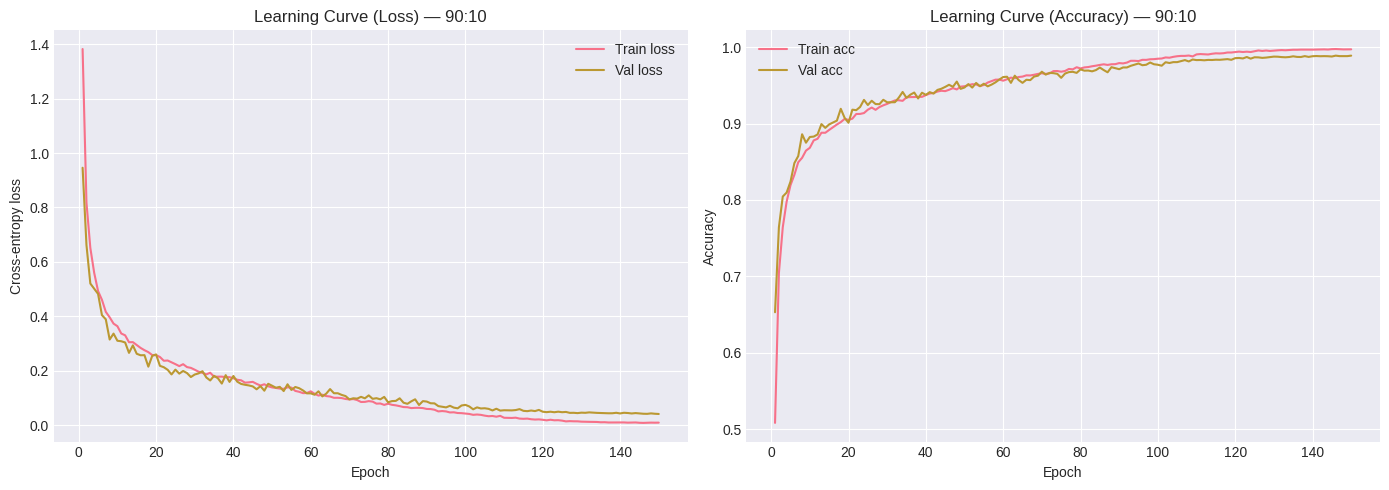

    Curves saved → curves_90_10.png


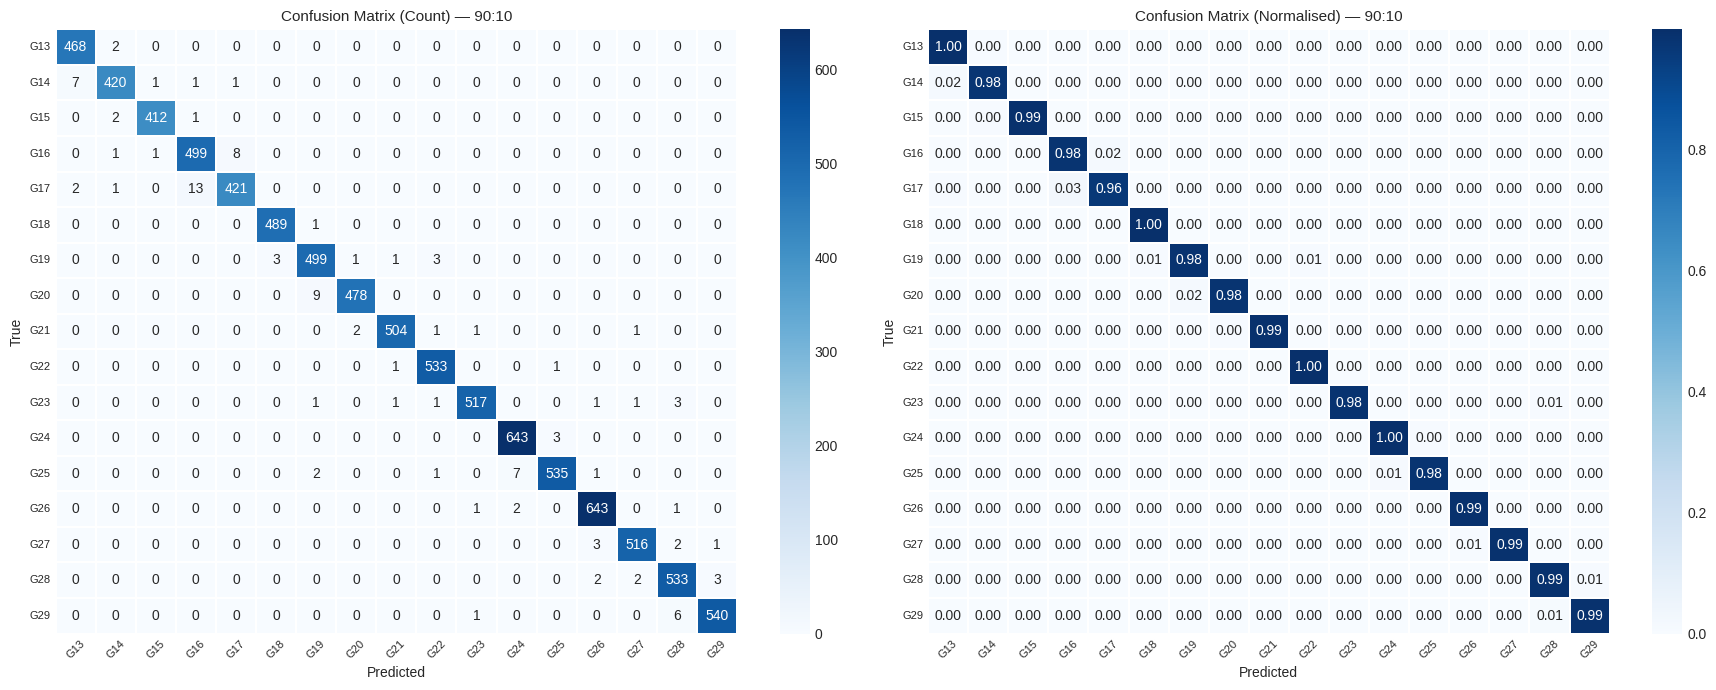

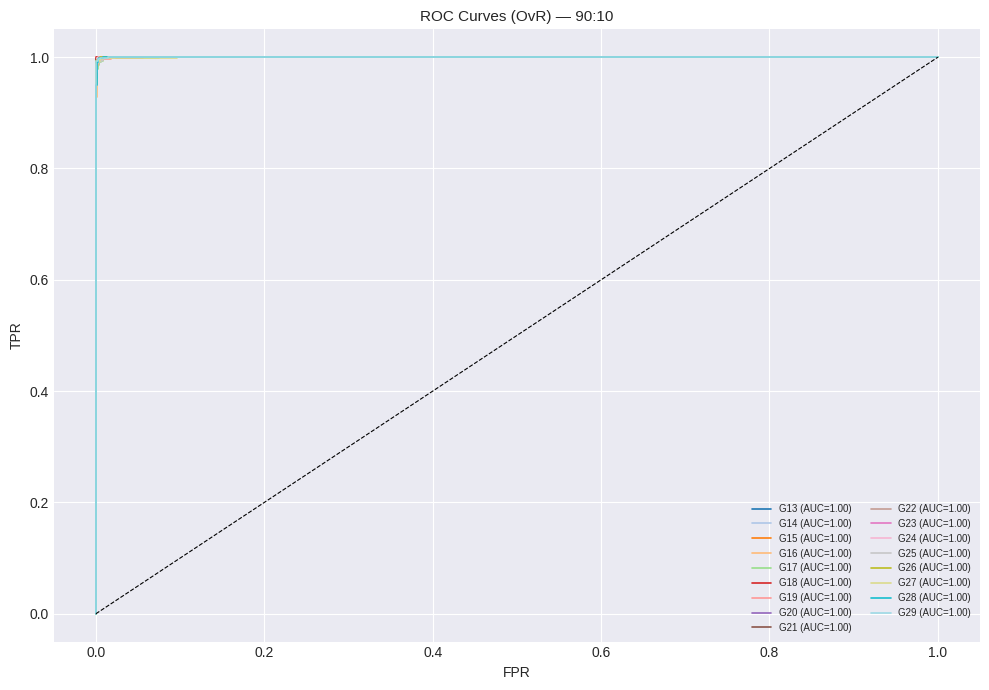


  Results  90:10
    Accuracy      : 0.9872
    Precision (W) : 0.9873
    Recall (W)    : 0.9872
    F1 (W)        : 0.9872
    ROC-AUC (W)   : 0.9999
    Train wall    : 2366.6 s
    Test wall     : 1.10 s
    GFLOPs/win    : -1.0000
    Model saved → mka_1d_cnn_90_10.pt

  FAILURE MODE ANALYSIS (Multi-Kernel Attention 1D CNN)

  Per-class mean accuracy (worst → best):
             G17  0.963  ████████████████████████████
             G14  0.977  █████████████████████████████
             G25  0.980  █████████████████████████████
             G16  0.980  █████████████████████████████
             G20  0.982  █████████████████████████████
             G19  0.984  █████████████████████████████
             G23  0.985  █████████████████████████████
             G28  0.987  █████████████████████████████
             G29  0.987  █████████████████████████████
             G27  0.989  █████████████████████████████
             G21  0.990  █████████████████████████████
             G15  0.9

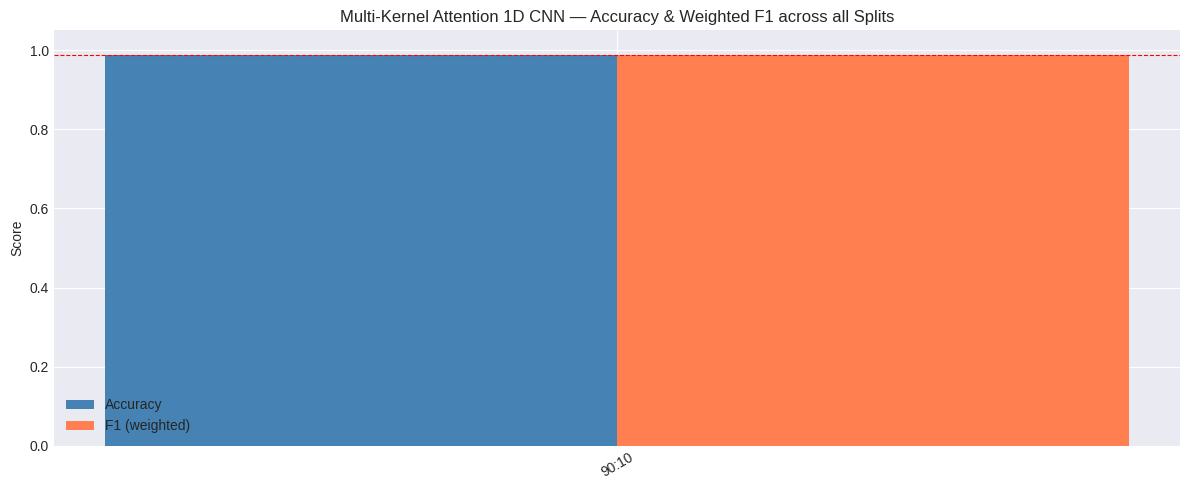

  Summary chart saved → summary_mka_all_splits.png

  FINAL SUMMARY (Multi-Kernel Attention 1D CNN)
split  train_size  test_size  accuracy  precision_w  recall_w     f1_w  roc_auc_w  train_wall_s  test_wall_s  gflops_per_window
90:10       70966       8762  0.987218     0.987253  0.987218 0.987214   0.999899   2366.598481     1.099135               -1.0

  Summary CSV → /kaggle/working/results_MKA/summary_mka_all_splits.csv
  Plots       → /kaggle/working/plots_MKA
  Models      → /kaggle/working/ckpts_MKA

 Best supervised baseline: split 90:10  (Weighted F1 = 0.9872)
  Use this as the reference for SSL experiments.



In [16]:
def main():
    print("\n" + "="*70)
    print("  STEP 1 — Loading NinaPro DB7  (Exercise B gestures 13-29)")
    print("="*70)
    subject_loader = SubjectLoader()
    available_sids, n_acc_ch = subject_loader.process_all(Config.SUBJECTS)

    print(f"\n  Available subjects : {available_sids}")
    print(f"  ACC channels       : {n_acc_ch}")

    print("\n" + "="*70)
    print("  STEP 2 — Building Windowed Dataset")
    print("="*70)
    X, y, n_channels = subject_loader.build_windows(available_sids, n_acc_ch)

    n_classes   = Config.GESTURE_MAX - Config.GESTURE_MIN + 1
    class_names = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]

    print(f"\n  Total windows   : {len(y):,}")
    print(f"  Input channels  : {n_channels}  (EMG=12, ACC={n_acc_ch})")
    print(f"  Window size     : {Config.WIN_SAMPLES} samples ({Config.WIN_MS} ms)")
    print(f"  Classes         : {n_classes}  → {class_names}")

    uniq, cnts = np.unique(y, return_counts=True)
    for u, c in zip(uniq, cnts):
        print(f"    {class_names[u]:>6s}: {c:>7,} windows ({c/len(y)*100:.1f}%)")

    print("\n" + "="*70)
    print("  STEP 3 — Training & Evaluation (Multi-Kernel Attention 1D CNN: 1 splits)")
    print("="*70)

    experiment  = SplitExperiment(X, y, n_channels, n_classes, class_names)
    all_metrics = []

    for train_frac, test_frac in Config.SPLIT_RATIOS:
        metrics, y_true, y_proba = experiment.run(train_frac, test_frac)
        all_metrics.append(metrics)
        
        tag  = metrics['split'].replace(':', '_')
        jpath = Config.RESULTS_DIR / f'metrics_mka_{tag}.json'
        m_save = {k: (v if not isinstance(v, dict) else v) for k, v in metrics.items()}
        with open(jpath, 'w') as f:
            json.dump(m_save, f, indent=2)
        gc.collect()

    best_split = analyse_failure_modes(all_metrics, class_names)

    rows = []
    for m in all_metrics:
        row = {k: v for k, v in m.items() if k != 'per_class_acc'}
        rows.append(row)
    df = pd.DataFrame(rows)
    csv_path = Config.RESULTS_DIR / 'summary_mka_all_splits.csv'
    df.to_csv(csv_path, index=False)

    print(f"\n{'='*70}")
    print("  FINAL SUMMARY (Multi-Kernel Attention 1D CNN)")
    print(f"{'='*70}")
    print(df[['split', 'train_size', 'test_size',
              'accuracy', 'precision_w', 'recall_w',
              'f1_w', 'roc_auc_w',
              'train_wall_s', 'test_wall_s',
              'gflops_per_window']].to_string(index=False))

    print(f"\n  Summary CSV → {csv_path}")
    print(f"  Plots       → {Config.PLOT_DIR}")
    print(f"  Models      → {Config.CKPT_DIR}")
    print(f"\n Best supervised baseline: split {best_split['split']}"
          f"  (Weighted F1 = {best_split['f1_w']:.4f})")
    print("  Use this as the reference for SSL experiments.\n")

if __name__ == '__main__':
    main()